# Calibrating parameters influencing runoff in the OGGM

In this notebook, we will calabrate the mass-balance parameters in the OGGM, these parameters will then be used to calculate the components of the runoff and the runoff variable itself. These variables will then be investigated to understand sensitvity against the calibrated parameters.

In this notebook we will:
1. Use the OGGM scalar calibration method
2. Show how users can calibrate parameters and use these for runoff outputs to understand impact of parameter changes.
3. Investigate variable sensitivity to the calibrations.

## Set Up

First install required packages to run this tutorial. 

We will be using level 4 data to allow for the dynamical spinup and the calibration capabilities.

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
import os

import oggm
from oggm import cfg, utils, workflow, tasks, graphics
from oggm.sandbox.edu import run_constant_climate_with_bias
import xarray as xr
from oggm.core import massbalance
from oggm.core.massbalance import mb_calibration_from_scalar_mb, mb_calibration_from_geodetic_mb

In [3]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
oggm.cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

2025-11-05 15:57:33: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-11-05 15:57:33: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-11-05 15:57:33: oggm.cfg: Multiprocessing: using all available processors (N=22)
2025-11-05 15:57:33: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2025-11-05 15:57:33: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2025-11-05 15:57:33: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [4]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2025-11-05 15:57:34: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2025-11-05 15:57:34: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


## Generating the Hydrological and Glaciological outputs

The pre-processed directories don't automatically have hydrological outputs, so lets run the `run_with_hydro` task below to calculate these! This requires a dynamical spinup, let's choose the time period 2000-2020.

In [5]:
# file identifier where the model output is saved
file_id = '_spinup'

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix='_spinup_historical')) as ds:
    ds = ds.sel(time=slice(2000, 2020)).load()

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # which climate scenario? See following notebook for other examples
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds = ds.isel(time=slice(0, -1)).load()

Now that we have the hydrological and glaciological outputs for our desired time period, lets calculate the total runoff for the glacier. There are four key variables that form the total runoff when summed together, and the process to calculate the runoff can be seen below.

The total runoff from the glacier is:
`runoff` = `melt_off_glacier` + `melt_on_glacier` + `liq_prcp_off_glacier` + `liq_prcp_on_glacier`


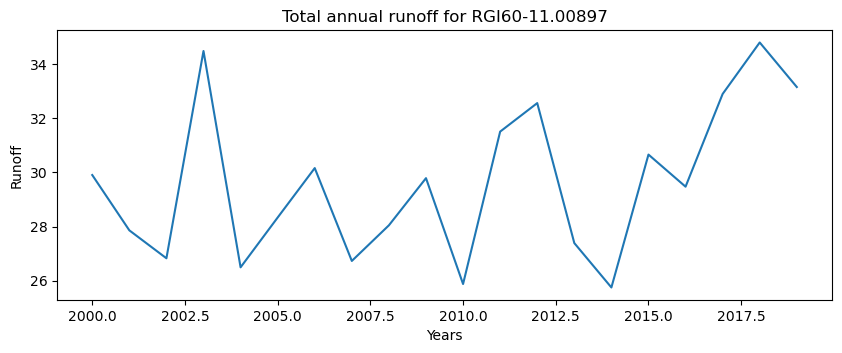

In [19]:
sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
df_annual = ds[sel_vars].to_dataframe()

# These summed variabels give the total runoff from the glacier
runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']

# Convert them to megatonnes (instead of kg)
df_runoff = df_annual[runoff_vars] * 1e-9
fig, ax = plt.subplots(figsize=(10, 3.5), sharex=True)
df_runoff.sum(axis=1).plot(ax=ax);
plt.ylabel('Runoff'); plt.xlabel('Years'); plt.title(f'Total annual runoff for {rgi_id}');


## Parameter Calibration

The mass-balance parameters at Level 4 are pre-calibrated automatically by the OGGM and stored in the dataframe. However there are flexible mass-balance calibration schemes in the OGGM.

In this tutorial, our aim is to calibrate the mass-balance parameters and investigate the impact that this calibration has on the run-off. In the OGGM we can currently (at the time of writing this tutorial October 2025) only calibrate the melt_f, prcp_fac and temp_bias parameters. We will calibrate these parameters using the **scalar mass balance** method, and investigate the relationship with the runoff components and the total runoff output.

For more information on the calibration methods, we would recommend the tutorial on mass-balance calibration [massbalance_calibration.ipynb](https://tutorials.oggm.org/stable/notebooks/tutorials/massbalance_calibration.html).

### **Calibration:** Scalar Mass Balance Calibration

Firstly comparing the mass balances below for in-situ observations and the default calibrated parameters. To understand the current behaviour of the mass balance output.


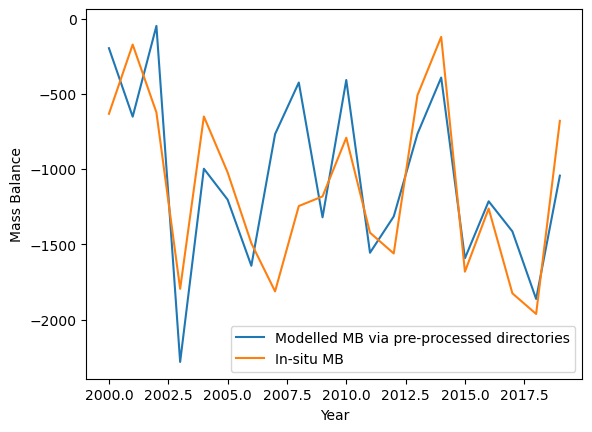

In [7]:
# First we get the insitu data for this glacier, since it exists
h, w = gdir_hef.get_inversion_flowline_hw()

mbmod = massbalance.MonthlyTIModel(gdir_hef)
mbdf= pd.DataFrame(index = np.arange(2000,2020,1))
mbdf['mod_mb'] = mbmod.get_specific_mb(fls=gdir_hef.read_pickle('inversion_flowlines'), year=np.arange(2000,2020,1))

mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

mbdf_in_situ = mbdf['in_situ_mb']

mbdf['mod_mb'].plot(label="Modelled MB via pre-processed directories")
mbdf['in_situ_mb'].plot(label="In-situ MB")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Mass Balance");

Now let's experiment by calibrating the parameters: these parameters are the melt factor (`melt_f`), the precipitation factor (`prcp_fac`) and the temperature bias (`temp_bias`). We will calibrate each parameter and permutations of the calibrations:
1. Just calibrating `melt_f`
2. Just calibrating `prcp_fac`
3. Just calibrating `temp_bias`
4. Calibrating `melt_f` and `prcp_fac`
5. Calibrating `prcp_fac` and `temp_bias`
6. Calibrating `melt_f` and `temp_bias`
7. Calibrating all parameters; `melt_f`, `prcp_fac` and `temp_bias`

The next calibration section will be relatively repetative, but take note of the parameters being calibrated and the inputs being used in the calibration process.

We will start the calibration by just calibrating the model the `melt_f` paramater.

### Single Parameter Calibration

In [8]:
ref_mb_df = utils.get_geodetic_mb_dataframe().loc[gdir_hef.rgi_id]
ref_mb_df = ref_mb_df.loc[ref_mb_df['period'] == cfg.PARAMS['geodetic_mb_period']].iloc[0]
# dmdtda: in meters water-equivalent per year -> we convert to kg m-2 yr-1
ref_mb = ref_mb_df['dmdtda'] * 1000
ref_mb

# Just calibrate the melt_f parameter
calib_param_melt_f = mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new melt_f
mb_melt_f = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_melt_f'] = mb_melt_f.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_melt_f:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_melt_f = ds_melt_f.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_melt_f.variables if 'month_2d' not in ds_melt_f[v].dims]
df_annual_melt_f = ds_melt_f[sel_vars].to_dataframe()


Now calibrating the precipitation factor variable, `prcp_fac`:

In [9]:
# Just calibrate the prcp_fac parameter
calib_param_prcp_fac = mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='prcp_fac',
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new prcp_fac
mb_prcp_fac = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_prcp_fac'] = mb_prcp_fac.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_prcp_fac:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_prcp_fac = ds_prcp_fac.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_prcp_fac.variables if 'month_2d' not in ds_prcp_fac[v].dims]
df_annual_prcp_fac = ds_prcp_fac[sel_vars].to_dataframe()

Now calibrating the temperature bias parameter, `temp_bias`:

In [10]:
# Just calibrate the temp_bias parameters
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='temp_bias',
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new temp_bias
mb_temp_bias = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_temp_bias'] = mb_temp_bias.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_temp_bias:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_temp_bias = ds_temp_bias.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_temp_bias.variables if 'month_2d' not in ds_temp_bias[v].dims]
df_annual_temp_bias = ds_temp_bias[sel_vars].to_dataframe()

### Calibrating permutations of two parameters together

Now calibrating `melt_f` and `prcp_fac`:

In [11]:
# Calibrating the melt_f and prcp_fac parameters together
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='melt_f',
                              calibrate_param2='prcp_fac',
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new melt_f and prcp_fac
mb_mf_pf = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_mf_pf'] = mb_mf_pf.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_mf_pf:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_mf_pf = ds_mf_pf.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_mf_pf.variables if 'month_2d' not in ds_mf_pf[v].dims]
df_annual_mf_pf = ds_mf_pf[sel_vars].to_dataframe()

Calibrating `prcp_fac` and `temp_bias`:

In [12]:
# Calibrating the prcp_fac and temp_bias parameters together
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='prcp_fac',
                              calibrate_param2='temp_bias',
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new prcp_fac and temp_bias
mb_pf_tb = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_pf_tb'] = mb_pf_tb.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_pf_tb:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_pf_tb = ds_pf_tb.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated prcp_fac parameter
sel_vars = [v for v in ds_pf_tb.variables if 'month_2d' not in ds_pf_tb[v].dims]
df_annual_pf_tb = ds_pf_tb[sel_vars].to_dataframe()

Calibrating `melt_f` and `temp_bias`:

In [13]:
# Calibrating the melt_f and temp_bias parameters together
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='melt_f',
                              calibrate_param2='temp_bias',
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new melt_f and temp_bias
mb_mf_tb = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_mf_tb'] = mb_mf_tb.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_mf_tb:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_mf_tb = ds_mf_tb.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_mf_tb.variables if 'month_2d' not in ds_mf_tb[v].dims]
df_annual_mf_tb = ds_mf_tb[sel_vars].to_dataframe()

Now calibrating `melt_f`, `prcp_fac` and `temp_bias` together at the same time:

### Calibrating all three parameters together

In [14]:
# Calibrate all of the parameters
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='melt_f',
                              calibrate_param2='prcp_fac',
                              calibrate_param3='temp_bias',
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new parameters
mb_calib = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_calib'] = mb_calib.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_calib:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_calib = ds_calib.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_calib.variables if 'month_2d' not in ds_calib[v].dims]
df_annual_calib = ds_calib[sel_vars].to_dataframe()

Now convert the runoff values to megatonnes for readability, and plotting runoff output values resulting from all calibration of parameters.

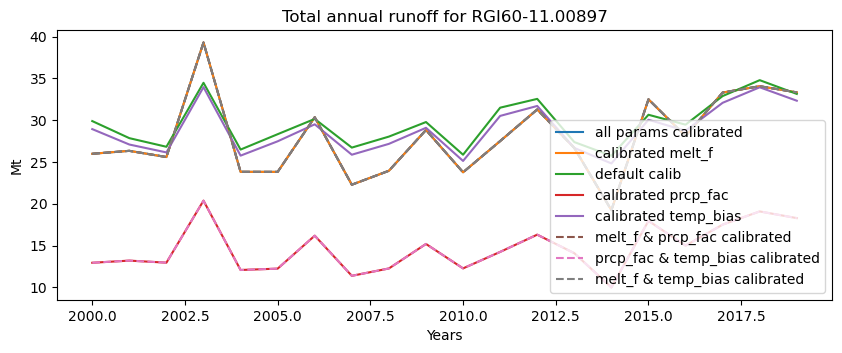

In [15]:
# Convert them to megatonnes (instead of kg)
df_runoff_melt_f = df_annual_melt_f[runoff_vars] * 1e-9
df_runoff_prcp_fac = df_annual_prcp_fac[runoff_vars] * 1e-9
df_runoff_temp_bias = df_annual_temp_bias[runoff_vars] * 1e-9
df_calib = df_annual_calib[runoff_vars] * 1e-9
df_runoff_mf_pf = df_annual_mf_pf[runoff_vars] * 1e-9
df_runoff_pf_tb = df_annual_pf_tb[runoff_vars] * 1e-9
df_runoff_mf_tb = df_annual_mf_tb[runoff_vars] * 1e-9

fig, ax = plt.subplots(figsize=(10, 3.5), sharex=True)
df_calib.sum(axis=1).plot(ax=ax, label='all params calibrated');
df_runoff_melt_f.sum(axis=1).plot(ax=ax, label='calibrated melt_f');
df_runoff.sum(axis=1).plot(ax=ax, label='default calib');
df_runoff_prcp_fac.sum(axis=1).plot(ax=ax, label='calibrated prcp_fac');
df_runoff_temp_bias.sum(axis=1).plot(ax=ax, label='calibrated temp_bias');
df_runoff_mf_pf.sum(axis=1).plot(ax=ax, label='melt_f & prcp_fac calibrated', linestyle='dashed');
df_runoff_pf_tb.sum(axis=1).plot(ax=ax, label='prcp_fac & temp_bias calibrated', linestyle='dashed');
df_runoff_mf_tb.sum(axis=1).plot(ax=ax, label='melt_f & temp_bias calibrated', linestyle='dashed');
plt.ylabel('Mt'); plt.xlabel('Years'); plt.title(f'Total annual runoff for {rgi_id}');
plt.legend();

It can be seen in the graph above that a few different permutation of parameters being tuned lead to the same runoff results.

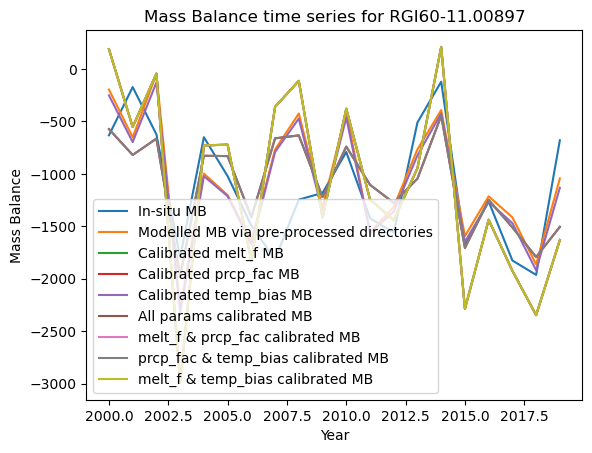

In [16]:
plt.plot(mbdf['in_situ_mb'], label='In-situ MB')
plt.plot(mbdf['mod_mb'], label='Modelled MB via pre-processed directories')
plt.plot(mbdf['mod_mb_melt_f'], label='Calibrated melt_f MB')
plt.plot(mbdf['mod_mb_prcp_fac'], label='Calibrated prcp_fac MB')
plt.plot(mbdf['mod_mb_temp_bias'], label='Calibrated temp_bias MB')
plt.plot(mbdf['mod_mb_calib'], label='All params calibrated MB')
plt.plot(mbdf['mod_mb_mf_pf'], label='melt_f & prcp_fac calibrated MB')
plt.plot(mbdf['mod_mb_pf_tb'], label='prcp_fac & temp_bias calibrated MB')
plt.plot(mbdf['mod_mb_mf_tb'], label='melt_f & temp_bias calibrated MB')
plt.legend()
plt.xlabel("Year")
plt.ylabel("Mass Balance");
plt.title(f'Mass Balance time series for {rgi_id}');

# Here, melt_f calibrated and all params calibrated give very similar results and overlap, similarly as within the run off timeseries

We now have these different mass-balance results based off of our combinations of parameter calibration.

We can now investigate a bit further, and investigate the relationship between `prcp_fac` and `melt_on_glacier`. We will do this by fixing the `prcp_fac` value and calibrating the `melt_f` to obtain a range of calibrated values. This will allow us to verify the sensitivity of these parameters.

## Sensitivity Analysis of runoff parameters in calibration

We will now investigate the sensitivity of the runoff parameters to the calibration of the mass-balance parameters below. This will allow us to understand the relationship between parameters further, for example if one parameter is changed, how much does this affect the other parameter?

And in this tutorial we will investigate the sensitivity `melt_on_glacier` parameter and the melt contribution, which is:

$ \frac{\text{melt on glacier}}{\text{runoff`}}$ over the `prcp_fac`.

We have chosen these parameters as `melt_on_glacier` is a single variable, defined by a linear relationship from the `prcp_fac`. Here we will just be affecting the  `melt_on_glacier` directly.

The melt contribution variable is a bit more complicated, as this will be investigating the relationship between the run off (which includes `melt_on_glacier`) and the `melt_on_glacier` variable.

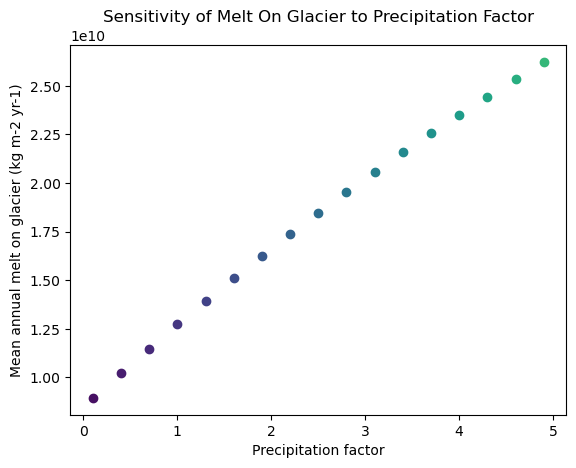

In [20]:
# Varying prcp_fac between a range of values with a step of 1.0

pd_prcp_sens = pd.DataFrame(index=np.arange(0.1, 5.0, 0.3))

# Calibrate the melt factor for each precipitation factor
spec_mb_melt_f_sens_dict = {}
for pf in pd_prcp_sens.index:
    calib_param = mb_calibration_from_scalar_mb(gdir_hef,
                                  ref_mb = ref_mb, 
                                  prcp_fac = pf,
                                  ref_period=cfg.PARAMS['geodetic_mb_period'],
                                  overwrite_gdir=True)
    
    # Fill the dataframe with the calibrated parameters
    pd_prcp_sens.loc[pf, 'melt_f'] = calib_param['melt_f']
    
    # Calculate the mass balance time series with the new melt_f
    mb_melt_f_sens = massbalance.MonthlyTIModel(gdir_hef)

    annual_mb = mb_melt_f_sens.get_specific_mb(h ,w, year=np.arange(2000,2020,1))
    spec_mb_melt_f_sens_dict[pf] = annual_mb

    # We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
    # Run this again with the calibrated parameters
    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                        run_task=tasks.run_from_climate_data, # running from observed climate data
                        ys=2000,  # Period which we will average and constantly repeat
                        init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                        store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                        output_filesuffix=file_id);  # an identifier for the output file, to read it later

    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_sens:
        # The last step of hydrological output is NaN (we can't compute it for this year)
        ds_sens = ds_sens.isel(time=slice(0, -1)).load()

    # Plot the runoff again for the calibrated melt_f parameter
    sel_vars = [v for v in ds_sens.variables if 'month_2d' not in ds_sens[v].dims]
    df_annual_sens = ds_sens[sel_vars].to_dataframe()

    pd_prcp_sens.loc[pf, 'melt_off_glacier'] = df_annual_sens['melt_off_glacier'].mean()
    pd_prcp_sens.loc[pf, 'melt_on_glacier'] = df_annual_sens['melt_on_glacier'].mean()
    pd_prcp_sens.loc[pf, 'liq_prcp_off_glacier'] = df_annual_sens['liq_prcp_off_glacier'].mean()
    pd_prcp_sens.loc[pf, 'liq_prcp_on_glacier'] = df_annual_sens['liq_prcp_on_glacier'].mean()
    pd_prcp_sens.loc[pf, 'runoff'] = pd_prcp_sens.loc[pf, 'melt_off_glacier'] + pd_prcp_sens.loc[pf, 'melt_on_glacier'] + pd_prcp_sens.loc[pf, 'liq_prcp_off_glacier'] + pd_prcp_sens.loc[pf, 'liq_prcp_on_glacier']

colors_melt_f = plt.get_cmap('viridis').colors[10::10]
plt.figure()
for j, pf in enumerate(pd_prcp_sens.index):
    plt.plot(pf, pd_prcp_sens.loc[pf, 'melt_on_glacier'], 'o', color=colors_melt_f[j])
    plt.xlabel('Precipitation factor')
    plt.ylabel('Mean annual melt on glacier (kg m-2 yr-1)')
    plt.title('Sensitivity of Melt On Glacier to Precipitation Factor')

# Here we are varying the precipitation factor and calibrating the melt factor for each value
# Then plotting the mean annual melt_on_glacier against the precipitation factor

In the above plot, a strong linear positive correlation is shown between the precipitation factor and the mean annual melt on the glacier. 

From the calibration, it can be seen that as the precipitation factor is changed, the melt factor parameter is calibrated accordingly and changes with the precipitation factor.

In the OGGM, the `melt_on_glacier` is derived from both the `melt_f` parameter and `prcp_fac`. Therefore this sensitivity makes sense.

Now investigating the sensitivity of the Glacier Melt Contribution to the Precipitation Factor.

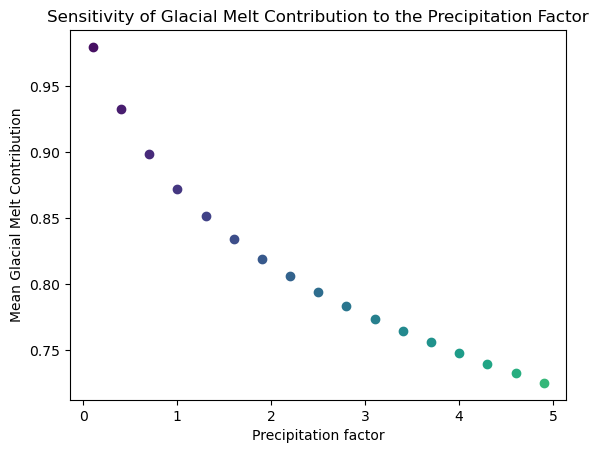

In [21]:
colors_melt_f = plt.get_cmap('viridis').colors[10::10]
plt.figure()
for j, pf in enumerate(pd_prcp_sens.index):
    plt.plot(pf, pd_prcp_sens.loc[pf, 'melt_on_glacier']/pd_prcp_sens.loc[pf, 'runoff'], 'o', color=colors_melt_f[j])
    plt.xlabel('Precipitation factor')
    plt.ylabel('Mean Glacial Melt Contribution')
    plt.title('Sensitivity of Glacial Melt Contribution to the Precipitation Factor')

# Here we are plotting how the glacial melt contribution (melt_on_glacier/runoff) varies with the changing precipitation factor
# This shows how the relative contribution of glacier melt to total runoff changes as we adjust precipitation

It can be seen that there is a relatively strong negative correlation, between the precipitation factor and the mean glacial melt contribution. And therefore it can be seen that the mean glacial melt contribution is sensitive to the change in precipitation factor.

Considering the melt contribution variable contains a numerator of `melt_on_glacier`, which has been shown to increase as the `prcp_fac` parameter increases.

The denominator is the runoff, which contains 4 summed variables (including `melt_on_glacier`) that are affected by the `prcp_fac`, all of which increase as the `prcp_fac` increases, as can be seen within the OGGM model implementation. The runoff therefore increases at least as much as the `melt_on_glacier`.

Therefore the increase of the denominator overpowers the increase of the numerator, and the relationship shown above reflects this reaction to the increase in `prcp_fac`.

## Exercise:

Try this yourself for sensitivity with the precipitation factor when varying the melt factor as above:
1. The melt_off_glacier parameter.
2. The total liquid precipitation parameters (sum of on and off).
3. Any other interesting combinations you can discover!

Does anything you discover surprise you?
Are there particularly sensitive parameters compared to others?

**Stretch:** Can you experiment different combinations of parameters for sensitvity, e.g. such as varying the temp_bias parameters instead? 